In [1]:
%load_ext autoreload
%autoreload 2

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Импортируем наши модули
from src.data.bars import create_volume_bars
from src.features.microstructure import MicrostructureEngine
from src.alpha_engine.generator import HybridAlphaEngine
from src.evaluation.walk_forward import WalkForwardEvaluator

sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (14, 8)

print("Скачиваем данные...")
df_raw = yf.download(tickers="BTC-USD", period="7d", interval="1m", progress=False)

if isinstance(df_raw.columns, pd.MultiIndex):
    df_raw.columns = df_raw.columns.droplevel(1)

ticks = pd.DataFrame({
    'price': df_raw['Close'],
    'volume': df_raw['Volume']
})
ticks.dropna(inplace=True)
print(f"Загружено {len(ticks)} 1-минутных 'тиков'.")

Скачиваем данные...
Загружено 9880 1-минутных 'тиков'.


In [2]:

vol_threshold = ticks['volume'].mean() * 15 # Подбираем порог
bars = create_volume_bars(ticks, volume_threshold=vol_threshold)
print(f"Сформировано {len(bars)} Volume Bars.")

engine = MicrostructureEngine(window=10)
features_df = engine.fit_transform(bars)
print(f"Данные с фичами: {features_df.shape}")
features_df.head()

Сформировано 529 Volume Bars.
Данные с фичами: (518, 9)


,open,high,low,close,volume,log_ret,roll_measure,ofi_proxy,parkinson_vol
timestamp,,,,,,,,,
2026-04-27 01:14:00+00:00,79156.242188,79221.906250,79141.976562,79141.976562,250929152,-0.000965,88.648389,48517120.0,0.001010
2026-04-27 01:17:00+00:00,79059.859375,79059.859375,79009.000000,79009.000000,127479808,-0.001682,0.000000,15666176.0,0.000605
2026-04-27 01:26:00+00:00,79011.593750,79074.242188,78960.000000,78960.000000,185643008,-0.000620,0.000000,-20332134.4,0.000635
2026-04-27 01:32:00+00:00,78822.000000,78972.562500,78822.000000,78972.562500,572948480,0.000159,0.000000,45512499.2,0.000731
2026-04-27 01:41:00+00:00,78857.210938,79143.820312,78857.210938,79116.867188,174592000,0.001826,0.000000,23917363.2,0.000984


In [3]:
import warnings
# Скрываем спам от pykoopman и sklearn
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=np.ComplexWarning)

# Снижаем порог до 50%, чтобы заставить стратегию торговать в нашем коротком окне 50 баров
alpha_engine = HybridAlphaEngine(tda_window=60, tda_percentile=50.0)

evaluator = WalkForwardEvaluator(
    train_window=300,
    test_window=50,
    commission=0.0005,
    slippage=0.0002
)

print("Запуск Walk-Forward бэктеста... (пожалуйста, подождите)")
oos_results = evaluator.walk_forward_eval(features_df, alpha_engine.generate_signals)

metrics = evaluator.get_summary(oos_results)
print("\nРезультаты OOS бэктеста:")
for k, v in metrics.items():
    print(f"{k}: {round(v, 4)}")

Запуск Walk-Forward бэктеста... (пожалуйста, подождите)

Результаты OOS бэктеста:
Sharpe Ratio: -1.12
Max Drawdown: -0.08
Total Return: -0.08


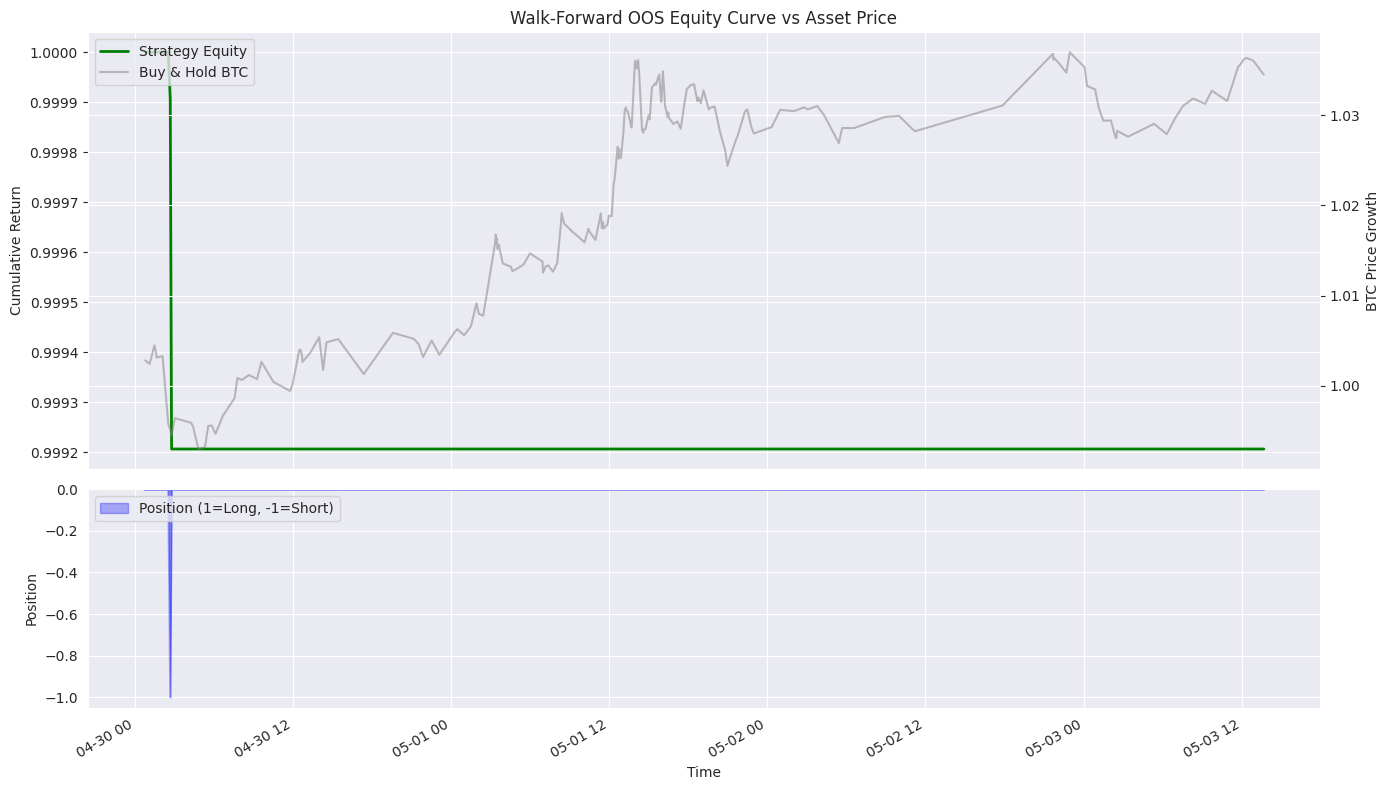

In [4]:
fig, (ax1, ax2) = plt.subplots(2, 1, gridspec_kw={'height_ratios':[2, 1]}, sharex=True)

ax1.plot(oos_results.index, oos_results['equity_curve'], color='green', label='Strategy Equity', linewidth=2)
ax1.set_ylabel("Cumulative Return")
ax1.set_title("Walk-Forward OOS Equity Curve vs Asset Price")

ax1_twin = ax1.twinx()
buy_and_hold = (1 + oos_results['market_return']).cumprod()
ax1_twin.plot(oos_results.index, buy_and_hold, color='gray', alpha=0.5, label='Buy & Hold BTC')
ax1_twin.set_ylabel("BTC Price Growth")

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left')

oos_results['position'].plot(ax=ax2, kind='area', stacked=False, color='blue', alpha=0.3, label='Position (1=Long, -1=Short)')
ax2.set_ylabel("Position")
ax2.set_xlabel("Time")
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()